# SRMS Candidate Detection: Datamine Validation Notebook

This notebook is the analysis and demonstration interface for the SRMS/reference-material candidate detector.

The reusable implementation remains in `run_srms_detection.py`. The notebook imports that script, runs the current approved pipeline, and presents the QC logic, result summaries, case studies, and validation questions for Datamine discussion.


## Previous/Baseline Approach

Earlier SRMS notebook work demonstrated project progression by extracting Standard/reference-material rows, engineering deviation and rolling features, applying rule flags, and using Isolation Forest as an initial anomaly detector.

That earlier work is useful academic evidence, but the duplicated notebook pipeline is now superseded by the script implementation. The current notebook keeps the business story and evidence, while avoiding a second copy of the detector logic.


## 1. SRMS Detection Overview

The current detector follows this QC-first order:

`Known Acceptance Limits -> Historical Behaviour -> Anomaly/Drift Detection -> Final Risk`

Known acceptance limits remain the primary rule. Machine learning supplements the QC rules by identifying unusual historical behaviour and gradual drift, but it does not override known limit failures.


In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

PROJECT_DIR = Path.cwd()
if PROJECT_DIR.name != "qc_anomaly_mvp":
    PROJECT_DIR = Path("/Users/linhlinh/Documents/New project/IFn735 Project/qc_anomaly_mvp")

if str(PROJECT_DIR) not in sys.path:
    sys.path.insert(0, str(PROJECT_DIR))

from run_srms_detection import (
    GROUP_COLUMNS,
    IFOREST_FEATURE_COLUMNS,
    IFOREST_TRAINING_MODE,
    SRMSConfig,
    add_final_risk,
    add_historical_features,
    add_isolation_forest,
    add_known_limit_features,
    add_drift_flags,
    create_summary,
    extract_srms_candidates,
    load_data,
    run_pipeline,
)

pd.set_option("display.max_columns", 80)
pd.set_option("display.width", 140)
plt.style.use("default")

print("Notebook imports complete.")
print("Project directory:", PROJECT_DIR)


Notebook imports complete.
Project directory: /Users/linhlinh/Documents/New project/IFn735 Project/qc_anomaly_mvp


## 2. Load Dataset and Configuration

This section loads the real ResultSet export and shows the thresholds used by the current MVP. These thresholds are intentionally configurable in the Python script.


In [2]:
SOURCE_PATH = Path("/Users/linhlinh/Downloads/ResultSet.csv")
config = SRMSConfig()
raw_df = load_data(str(SOURCE_PATH))

thresholds = pd.DataFrame([
    {"Setting": "Robust Z threshold", "Value": config.robust_z_threshold, "Classification": "Statistically motivated"},
    {"Setting": "Strong Robust Z threshold", "Value": config.strong_robust_z_threshold, "Classification": "Placeholder requiring Datamine validation"},
    {"Setting": "Rolling window", "Value": config.rolling_window, "Classification": "Placeholder requiring Datamine validation"},
    {"Setting": "Minimum history", "Value": config.min_history, "Classification": "Placeholder requiring Datamine validation"},
    {"Setting": "Minimum Isolation Forest history", "Value": config.min_iforest_history, "Classification": "Placeholder requiring Datamine validation"},
    {"Setting": "Isolation Forest contamination", "Value": config.contamination, "Classification": "Placeholder requiring Datamine validation"},
    {"Setting": "Warning fallback margin", "Value": config.warning_margin_pct, "Classification": "QC/business assumption"},
    {"Setting": "Drift slope percent threshold", "Value": config.drift_slope_pct_threshold, "Classification": "Placeholder requiring Datamine validation"},
    {"Setting": "Drift mean-shift percent threshold", "Value": config.drift_mean_shift_pct_threshold, "Classification": "Placeholder requiring Datamine validation"},
    {"Setting": "Drift consecutive points", "Value": config.drift_consecutive_points, "Classification": "Placeholder requiring Datamine validation"},
])

print(f"Loaded {len(raw_df):,} rows from {SOURCE_PATH}")
thresholds


Loaded 99,999 rows from /Users/linhlinh/Downloads/ResultSet.csv


,Setting,Value,Classification
0,Robust Z threshold,3.50,Statistically motivated
1,Strong Robust Z threshold,4.50,Placeholder requiring Datamine validation
2,Rolling window,5.00,Placeholder requiring Datamine validation
3,Minimum history,5.00,Placeholder requiring Datamine validation
4,Minimum Isolation Forest history,20.00,Placeholder requiring Datamine validation
5,Isolation Forest contamination,0.05,Placeholder requiring Datamine validation
6,Warning fallback margin,0.10,QC/business assumption
7,Drift slope percent threshold,0.50,Placeholder requiring Datamine validation
8,Drift mean-shift percent threshold,1.00,Placeholder requiring Datamine validation
9,Drift consecutive points,4.00,Placeholder requiring Datamine validation


## 3. Identify SRMS Candidates

The dataset does not contain an explicit SRMS subtype. Therefore, qualifying reference-material Standard records are treated as SRMS/reference-material candidates.

The current candidate logic uses `ANALYTICAL_TYPE == "Standard"`, a valid reference code, a numeric result, a target value, and lower/upper acceptance limits. It does not claim every selected record is confirmed SRMS.


In [3]:
candidate_df = extract_srms_candidates(raw_df)
group_sizes = candidate_df.groupby(GROUP_COLUMNS, dropna=False).size()

candidate_summary = pd.DataFrame([
    {"Metric": "Total ResultSet records", "Value": len(raw_df)},
    {"Metric": "Standard records", "Value": int(raw_df["ANALYTICAL_TYPE"].eq("Standard").sum())},
    {"Metric": "SRMS/reference-material candidates", "Value": len(candidate_df)},
    {"Metric": "Standard-Scheme-Analyte groups", "Value": len(group_sizes)},
    {"Metric": "Median group size", "Value": float(group_sizes.median())},
    {"Metric": "Rows with STD_CODE == SPECIFICATION_CODE", "Value": int(candidate_df["ReferenceCodeMatchesSpecification"].sum())},
])

candidate_summary


,Metric,Value
0,Total ResultSet records,99999.0
1,Standard records,36687.0
2,SRMS/reference-material candidates,36442.0
3,Standard-Scheme-Analyte groups,1034.0
4,Median group size,17.0
5,Rows with STD_CODE == SPECIFICATION_CODE,36442.0


In [4]:
candidate_examples = candidate_df[
    ["SRMSStandardCode", "SRMSLotCode", "SpecificationCode", "SchemeCode", "Analyte", "Value", "TargetValue", "LowerLimit", "UpperLimit"]
].head(8)

candidate_examples


,SRMSStandardCode,SRMSLotCode,SpecificationCode,SchemeCode,Analyte,Value,TargetValue,LowerLimit,UpperLimit
0,OREAS_501C,OREAS_501C,OREAS_501C,GE_IMS40Q12,AS,24.835165,23.90,21.010490,26.789510
1,OREAS_501C,OREAS_501C,OREAS_501C,GE_IMS40Q12,SE,2.263736,2.07,-3.137085,7.277085
2,OREAS_501C,OREAS_501C,OREAS_501C,GE_IMS40Q12,BI,0.675824,0.69,0.521019,0.858981
3,OREAS_501C,OREAS_501C,OREAS_501C,GE_IMS40Q12,TE,0.259341,0.25,0.100000,0.400000
4,OREAS_624,OREAS_624,OREAS_624,GE_IMS40Q12,BI,21.037736,22.30,19.969650,24.630350
5,OREAS_624,OREAS_624,OREAS_624,GE_IMS40Q12,AS,115.094340,109.00,97.598600,120.401400
6,OREAS_624,OREAS_624,OREAS_624,GE_IMS40Q12,TE,0.773585,0.75,0.549975,0.950025
7,OREAS_624,OREAS_624,OREAS_624,GE_IMS40Q12,SE,35.660377,30.10,22.090390,38.109610


## 4. Known Limit Detection

Each candidate result is compared with its target value and lower/upper acceptance limits. The script creates `LimitStatus` values:

- `PASS`: inside limits and not in warning state
- `WARNING`: close to a warning boundary or source status warning
- `FAIL`: outside acceptance limits or source status failure

`FAIL -> Critical` regardless of the machine-learning output.


In [5]:
limit_df = add_known_limit_features(candidate_df, config)
limit_status_summary = limit_df["LimitStatus"].value_counts().rename_axis("LimitStatus").reset_index(name="Count")
limit_status_summary["Percent"] = (limit_status_summary["Count"] / len(limit_df) * 100).round(2)
limit_status_summary


,LimitStatus,Count,Percent
0,PASS,24315,66.72
1,WARNING,6866,18.84
2,FAIL,5261,14.44


In [6]:
limit_sample = limit_df[
    ["SRMSStandardCode", "SchemeCode", "Analyte", "Value", "TargetValue", "LowerLimit", "UpperLimit", "WarningLower", "WarningUpper", "LimitStatus"]
].sample(8, random_state=42)

limit_sample


,SRMSStandardCode,SchemeCode,Analyte,Value,TargetValue,LowerLimit,UpperLimit,WarningLower,WarningUpper,LimitStatus
30845,OREAS_501C,GE_ICP40Q12,V,122.626912,120.00,102.996000,137.004000,109.212000,130.788000,PASS
34581,OREAS_502C,GE_ICP40Q12,PB,76.311178,23.50,16.149200,30.850800,18.837600,28.162400,FAIL
15751,OREAS_62F,GE_ICP40Q12,MO,1.038835,1.88,-0.808024,4.568024,0.175028,3.584972,PASS
24242,OREAS_908,GE_ICP40Q12,MO,8.994975,9.53,6.077281,12.982719,7.340006,11.719994,PASS
7577,OREAS_501C,GE_IMS40Q12,CU,2890.995213,2755.00,2479.500000,3030.500000,2580.333000,2929.667000,PASS
25866,OREAS_501C,GE_IMS40Q12,TE,0.191960,0.25,0.100000,0.400000,0.154850,0.345150,PASS
36184,OREAS_524,GE_IMS40Q12,BE,0.506609,0.46,0.163990,0.756010,0.272228,0.647772,PASS
7341,OREAS_624,GE_IMS40Q12,PB,5962.380862,6240.00,5614.752000,6865.248000,5843.136000,6636.864000,PASS


## 5. Historical Behaviour

Each result is compared only with earlier results from the same `Standard + Scheme + Analyte` group.

Important historical features shown here are historical median, MAD, Robust Z-score, rolling mean, and rolling slope. The current observation is not used in its own historical baseline.


In [7]:
historical_df = add_historical_features(limit_df, config)

historical_sample = historical_df.loc[historical_df["HistoryCount"].ge(config.min_history), [
    "SRMSStandardCode", "SchemeCode", "Analyte", "AnalysisDate", "Value", "HistoryCount",
    "HistoricalMedian", "HistoricalMAD", "RobustZScore", "RollingMean", "RollingSlope"
]].head(10)

historical_sample.round(4)


,SRMSStandardCode,SchemeCode,Analyte,AnalysisDate,Value,HistoryCount,HistoricalMedian,HistoricalMAD,RobustZScore,RollingMean,RollingSlope
474,OREAS_503C,GE_ICP40Q12,S,2020-07-02 08:56:01,0.5659,5,0.5666,0.0142,-0.0296,0.5618,0.0095
475,OREAS_624,GE_ICP40Q12,S,2020-07-02 08:56:01,13.8820,5,13.1061,0.1636,3.1996,12.9744,0.1542
477,OREAS_624,GE_ICP40Q12,FE,2020-07-02 08:56:49,16.5334,5,16.0075,0.2538,1.3975,16.1885,0.0047
618,OREAS_503C,GE_ICP40Q12,FE,2020-07-07 15:47:26,5.1031,5,4.9926,0.0608,1.2257,5.0104,-0.0050
621,OREAS_503C,GE_ICP40Q12,S,2020-07-07 15:47:26,0.6266,6,0.5663,0.0132,3.0800,0.5651,0.0066
629,OREAS_62F,GE_ICP40Q12,S,2020-07-08 04:48:58,0.1926,5,0.2021,0.0130,-0.4925,0.2034,-0.0077
653,OREAS_62F,GE_ICP40Q12,S,2020-07-08 06:43:34,0.2037,6,0.1977,0.0073,0.5590,0.1983,-0.0054
658,OREAS_502C,GE_ICP40Q12,S,2020-07-08 06:49:31,0.7909,5,0.7931,0.0240,-0.0619,0.8161,-0.0036
737,OREAS_62F,GE_ICP40Q12,ZN,2020-07-08 11:53:29,55.3268,5,62.1089,3.9411,-1.1607,64.6225,-3.7453
738,OREAS_62F,GE_ICP40Q12,BI,2020-07-08 11:53:29,-15.4146,5,-10.3061,2.6510,-1.2998,-7.2446,-0.3361


## 6. Isolation Forest

The MVP uses a hybrid approach:

- historical context is calculated per `Standard-Scheme-Analyte` group;
- one Isolation Forest is trained across eligible candidate records;
- only normalized or group-relative features are used.

`IForestTrainingMode = batch_retrospective`. This is suitable for retrospective MVP analysis, but it is not yet strict real-time point-in-time scoring.


In [8]:
print("Isolation Forest training mode:", IFOREST_TRAINING_MODE)
print("Isolation Forest features:")
for feature in IFOREST_FEATURE_COLUMNS:
    print("-", feature)


Isolation Forest training mode: batch_retrospective
Isolation Forest features:
- DeviationPct
- RobustZScore
- WithinRangePct
- RollingSlopePct
- RollingMeanShiftPct
- RollingMeanDiffPctTarget
- DiffFromPreviousPctTarget
- DistanceToLowerPctSpan
- DistanceToUpperPctSpan
- RollingStdPctTarget


## 7. Drift Detection

Drift detection looks for gradual movement even when individual results have not failed acceptance limits.

Example pattern: `99.8 -> 100.0 -> 100.4 -> 100.9 -> 101.5 -> 102.1`

The current rules use rolling slope, rolling mean shift, consecutive movement, and movement away from target.


In [9]:
# Show the rule settings rather than reimplementing the drift logic here.
pd.DataFrame([
    {"Drift input": "RollingSlopePct", "Current threshold": config.drift_slope_pct_threshold},
    {"Drift input": "RollingMeanShiftPct", "Current threshold": config.drift_mean_shift_pct_threshold},
    {"Drift input": "Consecutive movement", "Current threshold": config.drift_consecutive_points},
    {"Drift input": "Movement away from target", "Current threshold": "required"},
])


,Drift input,Current threshold
0,RollingSlopePct,0.5
1,RollingMeanShiftPct,1.0
2,Consecutive movement,4
3,Movement away from target,required


## 8. Final Risk Classification

| Condition | Final Risk |
| --- | --- |
| Within limits and historically normal | Low |
| Historical anomaly or drift | Medium |
| Warning + strong anomaly/drift | High |
| Acceptance-limit failure | Critical |

Known limit failure overrides the machine-learning model.


## 9. Run Complete Pipeline

The full detector is run from the reusable Python implementation. The notebook keeps this deliberately short so the script remains the source of truth.


In [10]:
results = run_pipeline(raw_df, config)
summary = create_summary(results)

summary


,FinalRiskLevel,Count,Percent
0,Low,29071,79.77
1,Medium,1386,3.80
2,High,724,1.99
3,Critical,5261,14.44


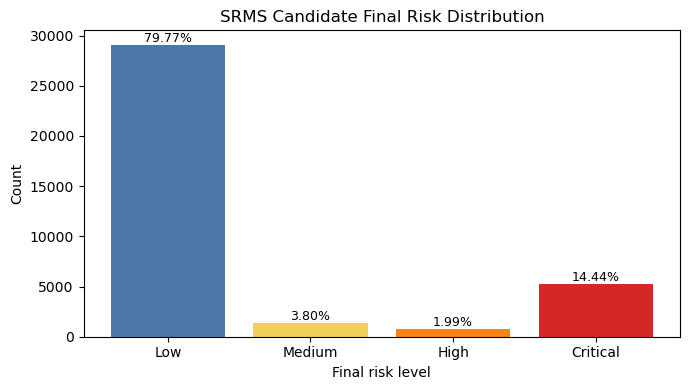

In [11]:
fig, ax = plt.subplots(figsize=(7, 4))
colors = ["#4C78A8", "#F2CF5B", "#F58518", "#D62728"]
ax.bar(summary["FinalRiskLevel"].astype(str), summary["Count"], color=colors)
ax.set_title("SRMS Candidate Final Risk Distribution")
ax.set_xlabel("Final risk level")
ax.set_ylabel("Count")
for i, row in summary.reset_index(drop=True).iterrows():
    ax.text(i, row["Count"], f'{row["Percent"]:.2f}%', ha="center", va="bottom", fontsize=9)
plt.tight_layout()
plt.show()


## 10. Detection Summary

These are detection counts and eligibility diagnostics, not accuracy metrics. Reliable ground-truth anomaly labels are not available in the current dataset.


In [12]:
eligible_iforest = results["HistoryCount"].ge(config.min_iforest_history)
detection_summary = pd.DataFrame([
    {"Metric": "Candidate rows", "Value": len(results)},
    {"Metric": "Limit failures", "Value": int(results["LimitStatus"].eq("FAIL").sum())},
    {"Metric": "Robust Z anomalies", "Value": int(results["StatisticalAnomalyFlag"].sum())},
    {"Metric": "Isolation Forest anomalies", "Value": int(results["IForestAnomaly"].sum())},
    {"Metric": "Drift flags", "Value": int(results["DriftFlag"].sum())},
    {"Metric": "Isolation Forest eligible rows", "Value": int(eligible_iforest.sum())},
    {"Metric": "Isolation Forest eligible percent", "Value": round(float(eligible_iforest.mean() * 100), 2)},
])

detection_summary


,Metric,Value
0,Candidate rows,36442.00
1,Limit failures,5261.00
2,Robust Z anomalies,1781.00
3,Isolation Forest anomalies,1167.00
4,Drift flags,1381.00
5,Isolation Forest eligible rows,23337.00
6,Isolation Forest eligible percent,64.04


In [13]:
group_diagnostics = pd.DataFrame([
    {"Metric": "Standard-Scheme-Analyte groups", "Value": len(group_sizes)},
    {"Metric": "Median group size", "Value": float(group_sizes.median())},
    {"Metric": "Groups with >= 5 observations", "Value": int(group_sizes.ge(5).sum())},
    {"Metric": "Groups with >= 20 observations", "Value": int(group_sizes.ge(20).sum())},
    {"Metric": "Groups with >= 50 observations", "Value": int(group_sizes.ge(50).sum())},
    {"Metric": "Groups with >= 100 observations", "Value": int(group_sizes.ge(100).sum())},
])

group_diagnostics


,Metric,Value
0,Standard-Scheme-Analyte groups,1034.0
1,Median group size,17.0
2,Groups with >= 5 observations,702.0
3,Groups with >= 20 observations,442.0
4,Groups with >= 50 observations,162.0
5,Groups with >= 100 observations,121.0


## 11. Datamine Validation Case Studies

The following cases are selected from the actual pipeline output. They show how the detector behaves for normal, early anomaly, drift, and known acceptance-limit failure examples.


In [14]:
CASE_COLUMNS = [
    "SRMSStandardCode", "SchemeCode", "Analyte", "AnalysisDate", "Value", "TargetValue", "LowerLimit", "UpperLimit",
    "LimitStatus", "RobustZScore", "IForestAnomaly", "DriftFlag", "FinalRiskLevel", "RiskReason", "SampleID", "HistoryCount"
]

case_filters = {
    "Case 1 - Normal / Low": results[
        results["FinalRiskLevel"].eq("Low")
        & results["LimitStatus"].eq("PASS")
        & ~results["StatisticalAnomalyFlag"]
        & ~results["IForestAnomaly"]
        & ~results["DriftFlag"]
        & results["HistoryCount"].ge(config.min_history)
    ],
    "Case 2 - Early Anomaly / Medium": results[
        results["FinalRiskLevel"].eq("Medium")
        & results["LimitStatus"].eq("PASS")
        & (results["StatisticalAnomalyFlag"] | results["IForestAnomaly"])
    ],
    "Case 3 - Drift / Medium or High": results[
        results["DriftFlag"]
        & results["LimitStatus"].ne("FAIL")
        & results["FinalRiskLevel"].isin(["Medium", "High"])
    ],
    "Case 4 - Acceptance-Limit Failure / Critical": results[
        results["FinalRiskLevel"].eq("Critical")
        & results["LimitStatus"].eq("FAIL")
    ],
}

selected_cases = []
for label, frame in case_filters.items():
    if frame.empty:
        continue
    sort_columns = ["HistoryCount", "RobustZScore"] if "Anomaly" in label else ["HistoryCount"]
    ascending = [False, False] if "Anomaly" in label else [False]
    row = frame.assign(_abs_z=frame["RobustZScore"].abs()).sort_values(["HistoryCount", "_abs_z"], ascending=[False, False]).iloc[0]
    selected_cases.append({"Case": label, **row[CASE_COLUMNS].to_dict()})

cases_df = pd.DataFrame(selected_cases)
cases_df.round(4)


,Case,SRMSStandardCode,SchemeCode,Analyte,AnalysisDate,Value,TargetValue,LowerLimit,UpperLimit,LimitStatus,RobustZScore,IForestAnomaly,DriftFlag,FinalRiskLevel,RiskReason,SampleID,HistoryCount
0,Case 1 - Normal / Low,OREAS_905,GE_IMS40Q12,ZN,2021-11-22 16:35:49,143.4438,138.00,124.1448,151.8552,PASS,0.4447,False,False,Low,inside limits and historically normal,TSV_LB0016663011-13,259
1,Case 2 - Early Anomaly / Medium,OREAS_502C,GE_IMS40Q12,SE,2021-11-10 07:01:18,5.1465,3.40,-1.9400,8.7400,PASS,4.0261,False,False,Medium,historical robust z-score anomaly,TSV_LB0015957009-125,216
2,Case 3 - Drift / Medium or High,OREAS_905,GE_IMS40Q12,MO,2021-10-06 09:38:18,2.9671,3.27,2.8181,3.7219,WARNING,-1.3956,False,True,High,close to acceptance limit; drift/trend detected,TSV_LB0014380676-950,259
3,Case 4 - Acceptance-Limit Failure / Critical,OREAS_905,GE_IMS40Q12,PB,2021-11-22 16:37:52,55.6396,30.40,26.1106,34.6894,FAIL,9.8777,True,False,Critical,outside known acceptance limits; historical ro...,TSV_LB0016663011-1,259


,SRMSStandardCode,SchemeCode,Analyte,AnalysisDate,Value,TargetValue,LowerLimit,UpperLimit,LimitStatus,RobustZScore,IForestAnomaly,DriftFlag,FinalRiskLevel,RiskReason,SampleID,HistoryCount,Case
0,OREAS_905,GE_IMS40Q12,ZN,2021-11-22 16:35:49,143.4438,138.0,124.1448,151.8552,PASS,0.4447,False,False,Low,inside limits and historically normal,TSV_LB0016663011-13,259,Case 1 - Normal / Low


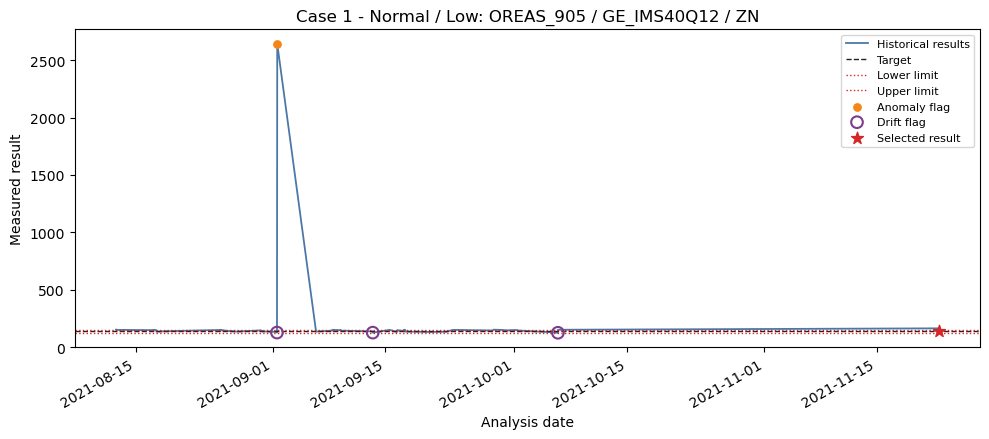

,SRMSStandardCode,SchemeCode,Analyte,AnalysisDate,Value,TargetValue,LowerLimit,UpperLimit,LimitStatus,RobustZScore,IForestAnomaly,DriftFlag,FinalRiskLevel,RiskReason,SampleID,HistoryCount,Case
0,OREAS_502C,GE_IMS40Q12,SE,2021-11-10 07:01:18,5.1465,3.4,-1.94,8.74,PASS,4.0261,False,False,Medium,historical robust z-score anomaly,TSV_LB0015957009-125,216,Case 2 - Early Anomaly / Medium


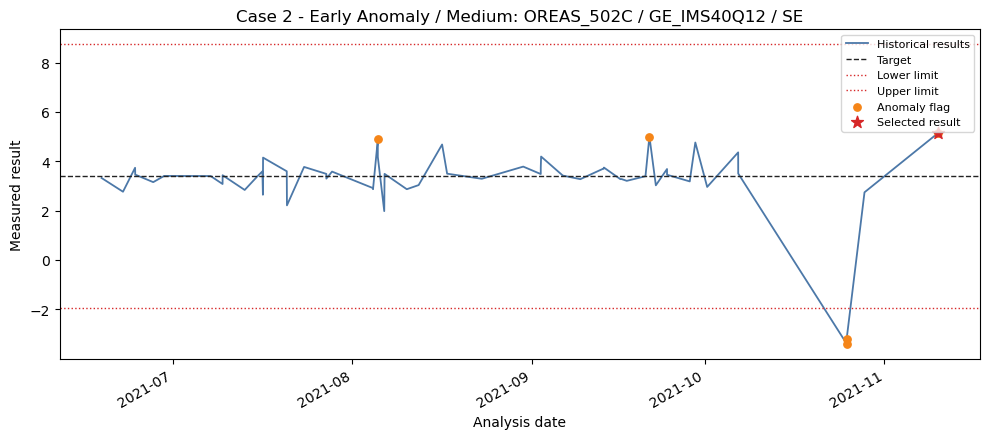

,SRMSStandardCode,SchemeCode,Analyte,AnalysisDate,Value,TargetValue,LowerLimit,UpperLimit,LimitStatus,RobustZScore,IForestAnomaly,DriftFlag,FinalRiskLevel,RiskReason,SampleID,HistoryCount,Case
0,OREAS_905,GE_IMS40Q12,MO,2021-10-06 09:38:18,2.9671,3.27,2.8181,3.7219,WARNING,-1.3956,False,True,High,close to acceptance limit; drift/trend detected,TSV_LB0014380676-950,259,Case 3 - Drift / Medium or High


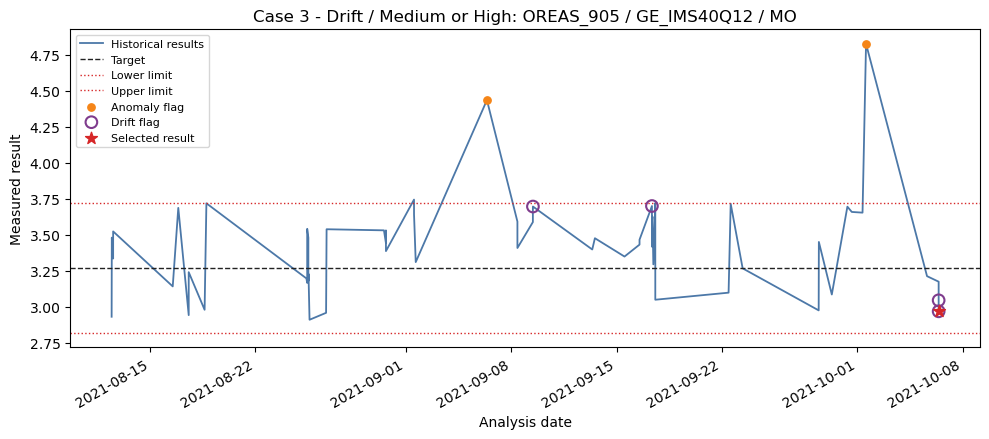

,SRMSStandardCode,SchemeCode,Analyte,AnalysisDate,Value,TargetValue,LowerLimit,UpperLimit,LimitStatus,RobustZScore,IForestAnomaly,DriftFlag,FinalRiskLevel,RiskReason,SampleID,HistoryCount,Case
0,OREAS_905,GE_IMS40Q12,PB,2021-11-22 16:37:52,55.6396,30.4,26.1106,34.6894,FAIL,9.8777,True,False,Critical,outside known acceptance limits; historical ro...,TSV_LB0016663011-1,259,Case 4 - Acceptance-Limit Failure / Critical


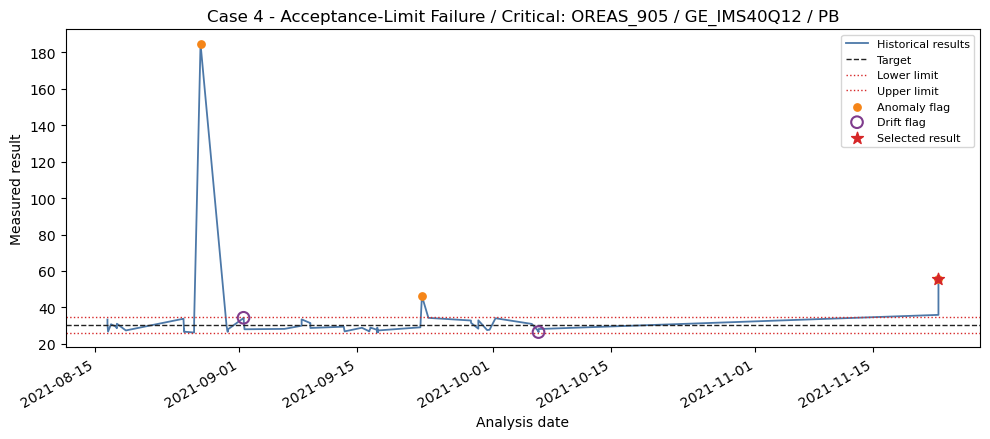

In [15]:
def plot_case(case_row):
    group_mask = True
    for column in GROUP_COLUMNS:
        group_mask = group_mask & results[column].eq(case_row[column])
    group_df = results.loc[group_mask].sort_values(["AnalysisDate", "SampleID"]).copy()

    selected_time = case_row["AnalysisDate"]
    if pd.notna(selected_time):
        plot_df = group_df[group_df["AnalysisDate"].le(selected_time)].tail(60)
    else:
        plot_df = group_df.tail(60)

    fig, ax = plt.subplots(figsize=(10, 4.5))
    ax.plot(plot_df["AnalysisDate"], plot_df["Value"], color="#4C78A8", linewidth=1.3, label="Historical results")
    ax.axhline(case_row["TargetValue"], color="#222222", linestyle="--", linewidth=1, label="Target")
    ax.axhline(case_row["LowerLimit"], color="#D62728", linestyle=":", linewidth=1, label="Lower limit")
    ax.axhline(case_row["UpperLimit"], color="#D62728", linestyle=":", linewidth=1, label="Upper limit")

    anomaly_rows = plot_df[plot_df["IForestAnomaly"] | plot_df["StatisticalAnomalyFlag"]]
    if not anomaly_rows.empty:
        ax.scatter(anomaly_rows["AnalysisDate"], anomaly_rows["Value"], color="#F58518", s=28, label="Anomaly flag", zorder=3)

    drift_rows = plot_df[plot_df["DriftFlag"]]
    if not drift_rows.empty:
        ax.scatter(drift_rows["AnalysisDate"], drift_rows["Value"], facecolors="none", edgecolors="#7F3C8D", s=70, linewidths=1.5, label="Drift flag", zorder=4)

    ax.scatter([case_row["AnalysisDate"]], [case_row["Value"]], color="#D62728", s=80, marker="*", label="Selected result", zorder=5)
    ax.set_title(f'{case_row["Case"]}: {case_row["SRMSStandardCode"]} / {case_row["SchemeCode"]} / {case_row["Analyte"]}')
    ax.set_xlabel("Analysis date")
    ax.set_ylabel("Measured result")
    ax.legend(loc="best", fontsize=8)
    fig.autofmt_xdate()
    plt.tight_layout()
    plt.show()

for _, case_row in cases_df.iterrows():
    display(pd.DataFrame([case_row[CASE_COLUMNS + ["Case"]].to_dict()]).round(4))
    plot_case(case_row)


## Questions for Datamine Validation

1. Are the OREAS Standard records in this dataset the reference-material results that should be assessed by the SRMS detector?
2. Does the Low / Medium / High / Critical interpretation match laboratory QC expectations?
3. Are the current warning and drift rules appropriate?
4. Is a rolling window of 5 results reasonable?
5. Should drift thresholds be based on acceptance-limit span, method precision, or another laboratory rule?
6. Is the current Robust Z-score threshold of 3.5 appropriate?
7. Is the current Isolation Forest contamination assumption of 5% reasonable, or should anomaly prevalence not be predefined?
8. How should analytes with target values close to zero be handled?
9. Is retrospective analysis sufficient for the intended product, or will production eventually require point-in-time / real-time detection?


## Interpretation Notes

This notebook is designed for Datamine validation and academic reporting. It prioritises business/QC logic, result summaries, selected examples, and stakeholder questions over implementation detail.

The Isolation Forest component is retrospective in the current MVP. Historical statistics are leakage-safe, but the batch model itself is not yet a strict real-time scoring architecture.
